In [1]:
import random
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import anndata as ad
import scanorama

import timeit
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
from CellPos.preprocessing import preprocess
from CellPos.train import SpaceReconstructor, evaluate

## Date Loading

### 10X

In [3]:
# 10X
data_obj = sc.read_h5ad("/.../Mouse_Brain/adata_coronal.h5ad")

st_meta=data_obj[data_obj.obs['library_id'] == 'adata_coronal_2']
st_meta.obs.index=st_meta.obs.index.str.replace('-adata_coronal_2', '', regex=False)

print(st_meta)

View of AnnData object with n_obs × n_vars = 2807 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'cluster'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'spatial', 'umap'
    obsm: 'X_scanorama', 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances'


In [4]:
st_obj=sc.datasets.visium_sge(sample_id="V1_Adult_Mouse_Brain_Coronal_Section_2")

st_obj.obs['cluster']=st_meta.obs['cluster']

st_obj = st_obj[~st_obj.obs['cluster'].isna()].copy()

st_obj.obs['cluster'] = st_obj.obs['cluster'].astype(int).values

label_encoder = LabelEncoder()
st_obj.obs['label'] = label_encoder.fit_transform(st_obj.obs['cluster'])

print(st_obj)

AnnData object with n_obs × n_vars = 2807 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'label'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [5]:
st_obj.var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'Lypla1',
       ...
       'Gm16367', 'AC163611.1', 'AC163611.2', 'AC140365.1', 'AC124606.2',
       'AC124606.1', 'AC133095.2', 'AC133095.1', 'AC234645.1', 'AC149090.1'],
      dtype='object', length=32285)

### MerFish

In [6]:
sc_obj = sc.read_h5ad("/home/xiaoxuanwang/data/Mouse_Brain/WB_MERFISH_animal1_coronal.h5ad")
sc_obj.obsm['spatial'] = sc_obj.obsm['X_spatial_coords']
sc_obj

AnnData object with n_obs × n_vars = 4167869 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap', 'spatial'

In [7]:
# print("切片数量:", sc_obj.obs['brain_section_label'].nunique())

In [8]:
section_data = sc_obj[sc_obj.obs['brain_section_label'] == 'C57BL6J-1.080']
section_data

View of AnnData object with n_obs × n_vars = 51112 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap', 'spatial'

In [9]:
section_data.var_names = section_data.var['gene_name'].values
section_data.var_names 

Index(['Htr7', 'Gzmk', 'Arhgap36', 'Sema3c', 'Rxrg', 'Itga8', 'Glp2r', 'Ramp3',
       'Car12', 'Chn2',
       ...
       'Galnt14', 'Kcnh8', 'Pifo', 'Epb41l4a', 'Matn2', 'Gata3', 'Fat1',
       'Zim1', 'Lmo1', 'Cntnap3'],
      dtype='object', length=1120)

In [10]:
section_data = section_data[
    section_data.obs['major_brain_region'].notna() & 
    (section_data.obs['major_brain_region'].astype(str).str.lower() != 'nan')
].copy()

In [11]:
section_data

AnnData object with n_obs × n_vars = 49418 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap', 'spatial'

## Date Processing

In [12]:
sc_adata, st_adata = preprocess(sc_adata=section_data,  st_adata=st_obj, # sc_adata=adata
                                sc_min_genes = 200, sc_min_cells = 5,
                                hvg_features=32285, svg_features=32285,  #hvg_features=4000, svg_features=4000, select_gene='intersection'
                                select_gene='union') # select_hvg='union' or 'intersection'

sc_adata: AnnData object with n_obs × n_vars = 8242 × 1052
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 't

## Training

In [13]:
reconstructor = SpaceReconstructor(device='cuda:1', seed=2026)
p_config = {'encoder': {'dropout': [0.2, 0, 0]},
             'decoder': {'dropout': [0.2, 0, 0]},
             'pred': {'dropout': [0.3, 0, 0]}}
sc_adata, st_adata, m_sc, m_st, m_p = reconstructor.fit(sc_adata, st_adata, 
                                                        lr = 0.002, 
                                                        pretrain_epoch_num=800, 
                                                        fulltrain_epoch_num=800,
                                                        custom_config=p_config,)

--- Phase 1: Pre-training ---


embedding_pretrain:  63%|████████████████████████████████████▉                      | 501/800 [01:03<00:38,  7.75it/s, loss=0.4262]

Epoch [500/800], Loss: 0.4285


embedding_pretrain: 100%|███████████████████████████████████████████████████████████| 800/800 [01:42<00:00,  7.81it/s, loss=0.4154]


--- Phase 2: Full Joint Training ---


full_training:  63%|████████████████████████████████████████▏                       | 502/800 [00:47<00:20, 14.86it/s, loss=0.2525]

Epoch [500/800], Loss: 0.2531


full_training: 100%|████████████████████████████████████████████████████████████████| 800/800 [01:08<00:00, 11.73it/s, loss=0.2488]


Total time: 171.02s


In [14]:
sc_adata.obsm['spatial']

array([[ 44485.28772408, -61098.8056387 ],
       [ 44492.33898127, -61210.5631103 ],
       [ 44499.59380965, -61169.25447197],
       ...,
       [ 39412.17286568, -64247.70409886],
       [ 39375.77787568, -64245.3008328 ],
       [ 39373.23057638, -64133.57327078]])

In [15]:
# sc_adata.obsm['spatial']
sc_adata.obsm['spatial_pred'][:, 1] = -1*sc_adata.obsm['spatial_pred'][:, 1]
sc_adata.obsm['spatial_pred']

array([[ 11350.99906671,  -5516.44573735],
       [ 14992.68741691,  -3010.6582774 ],
       [ 15564.4131552 ,  -3025.55135747],
       ...,
       [ 10327.81920224, -11398.8610878 ],
       [ 15245.62682986,  -8999.40565088],
       [ 16419.10014784,  -8253.33531991]])

## Evaluating

In [16]:
sc_adata.obs['cluster_pred'] = label_encoder.inverse_transform(sc_adata.obs['label_pred'])
sc_adata.obs['cluster_pred'] = sc_adata.obs['cluster_pred'].astype(str)
evaluate(sc_adata, compute_jsd_flag=True, label_col='major_brain_region')

100%|█████████████████████████████████████████████████████████████████████████████████████████| 8242/8242 [00:32<00:00, 251.78it/s]


For PCC: 0.9565,  PCC of pair distance: 0.6420
MSE: 1791748730.5466,  MAE: 40722.0233(±3087.1073 SD)
Hit_rate (10-20-50-100): 0, 1, 6, 16
Average JSD: 0.1388
--- Detailed JSD per Cell Type ---
                      Avg_JSD
Isocortex            0.064360
Hypothalamus         0.093627
Thalamus             0.158045
Hippocampus          0.167704
Striatum             0.189689
Olfactory            0.195076
Fiber_tracts         0.315138
Cortical_subplate    0.317803
Ventricular_systems  0.354394
Pallidum             0.383927


## Evaluating

In [17]:
colors = ["#0C4E9B","#5F97C6",#"#638DEE","#5F97C6","#8FDBF3",
          "#E11E25","#EE9094",#"#DB6C76","#EE9094","#F2CDCF",
          "#F38B2F","#F7BF6C",#"#F1B543","#F7BF6C","#FBDF9D",
          "#2E8A57","#BCD896",#"#03C088","#BCD896","#BEEFBF",
          "#734E9C","#9999CC",#"#6D65A3","#9999CC","#C6C3E1",
          "#972D36","#D4A55B",#"#C55645","#D4A55B","#C6B598", 
         ]

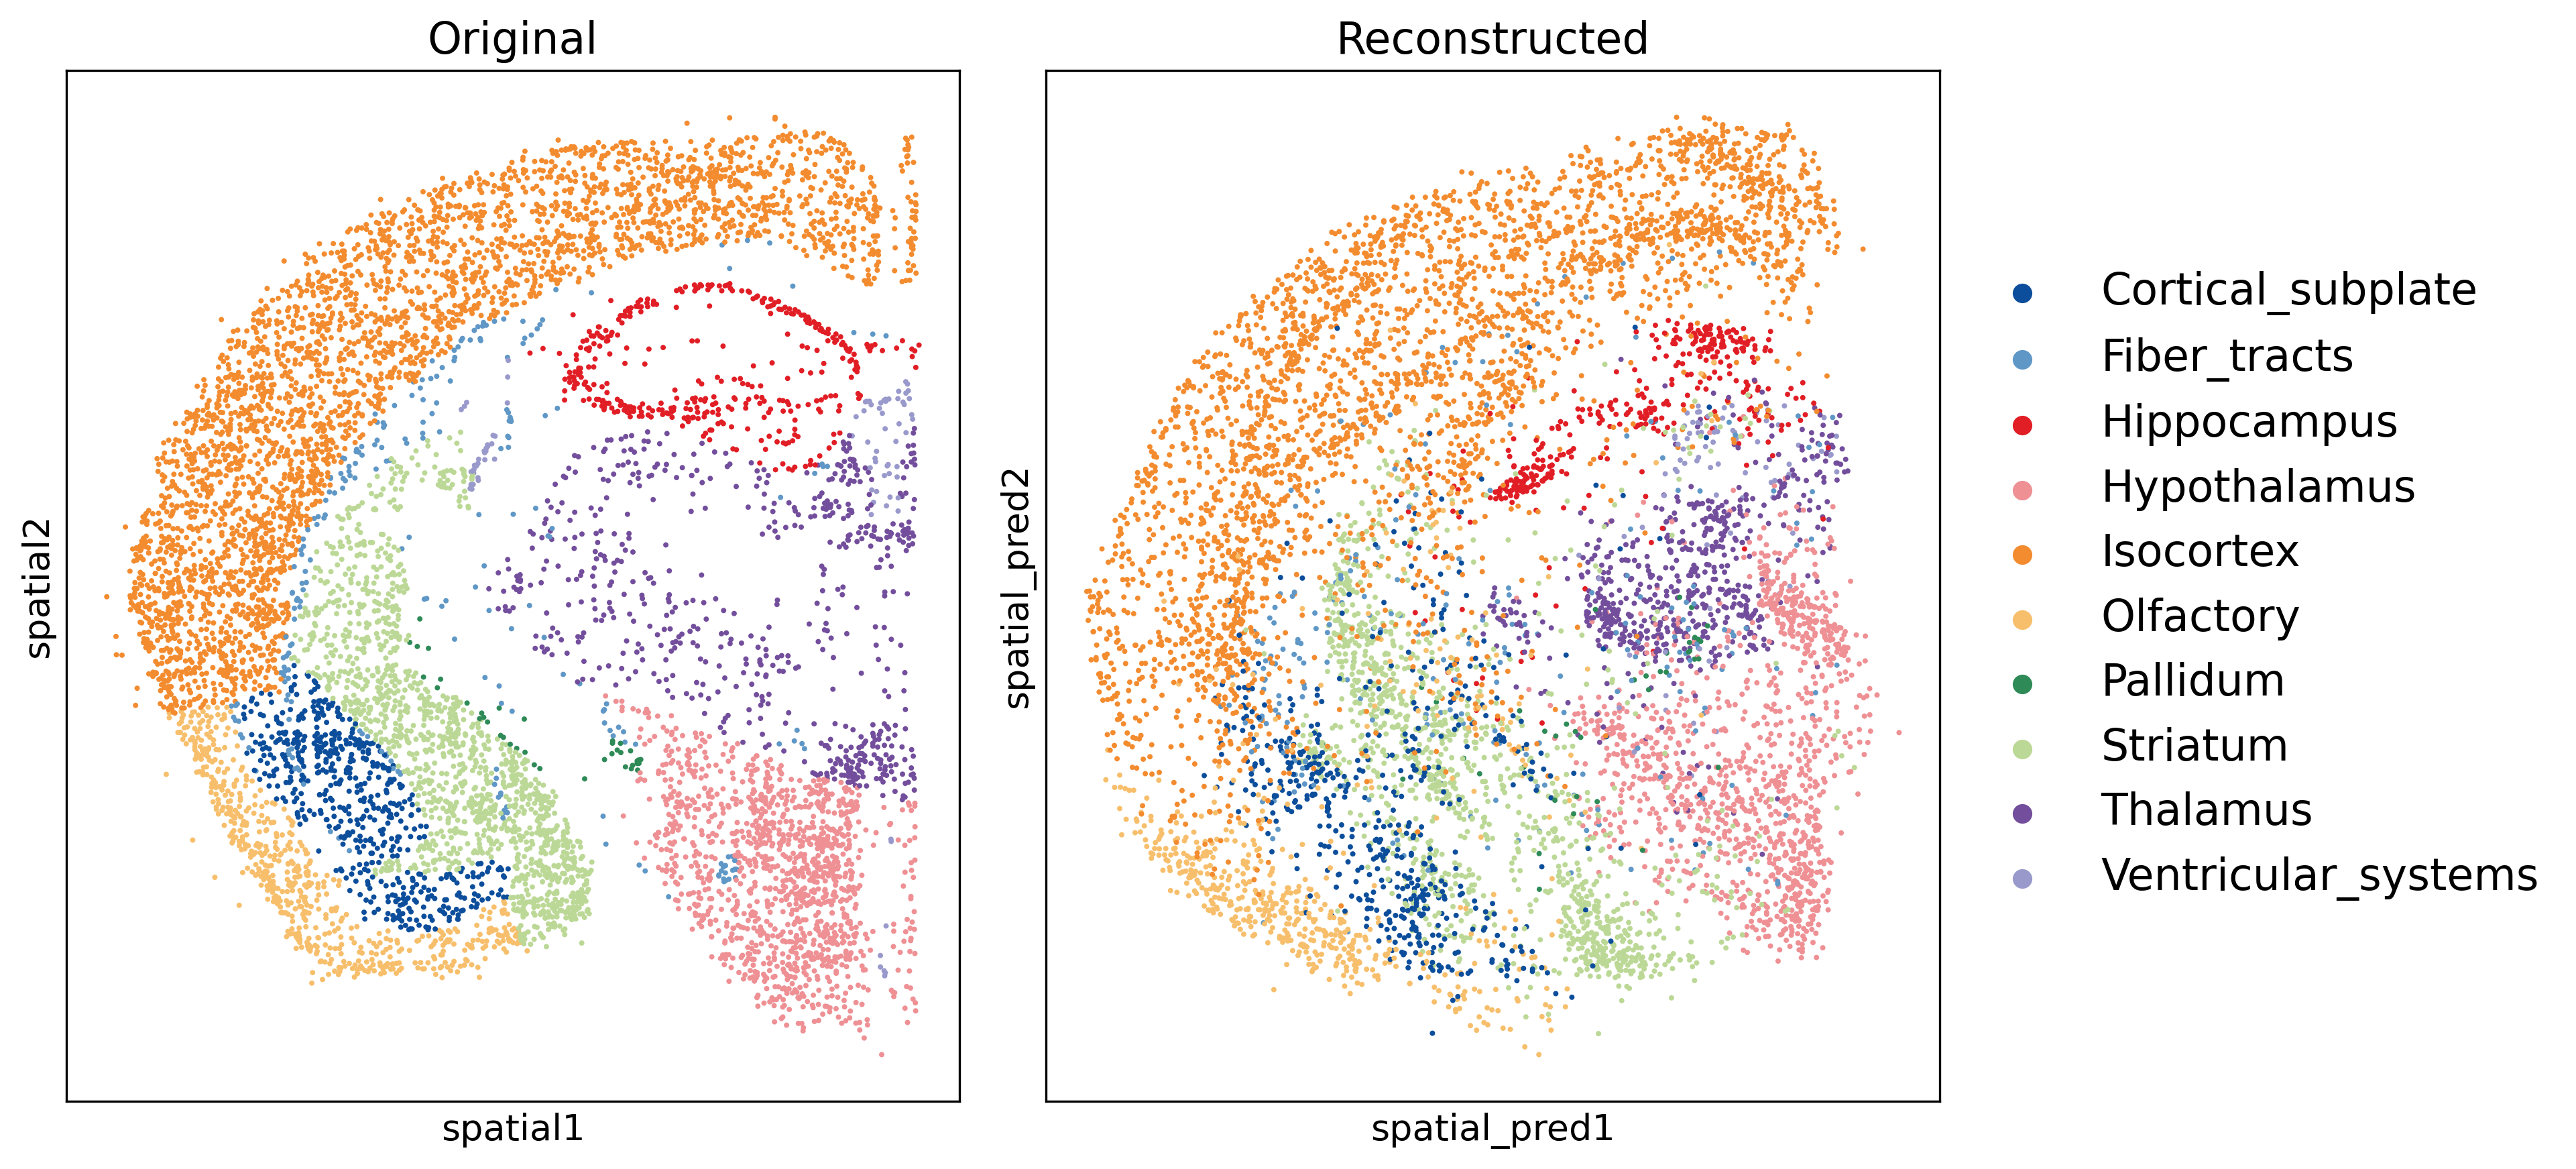

In [18]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 13
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plt.sca(axes[0])
sc.pl.embedding(sc_adata, basis='spatial', color='major_brain_region', palette = colors, title='Original',
                show=False, legend_loc=None, ax=axes[0]) # basis='spatial_normalized'
plt.sca(axes[1])
sc.pl.embedding(sc_adata, basis='spatial_pred', color='major_brain_region', palette = colors, title='Reconstructed',
                legend_fontsize='large', show=False, ax=axes[1])
plt.tight_layout()
plt.show()

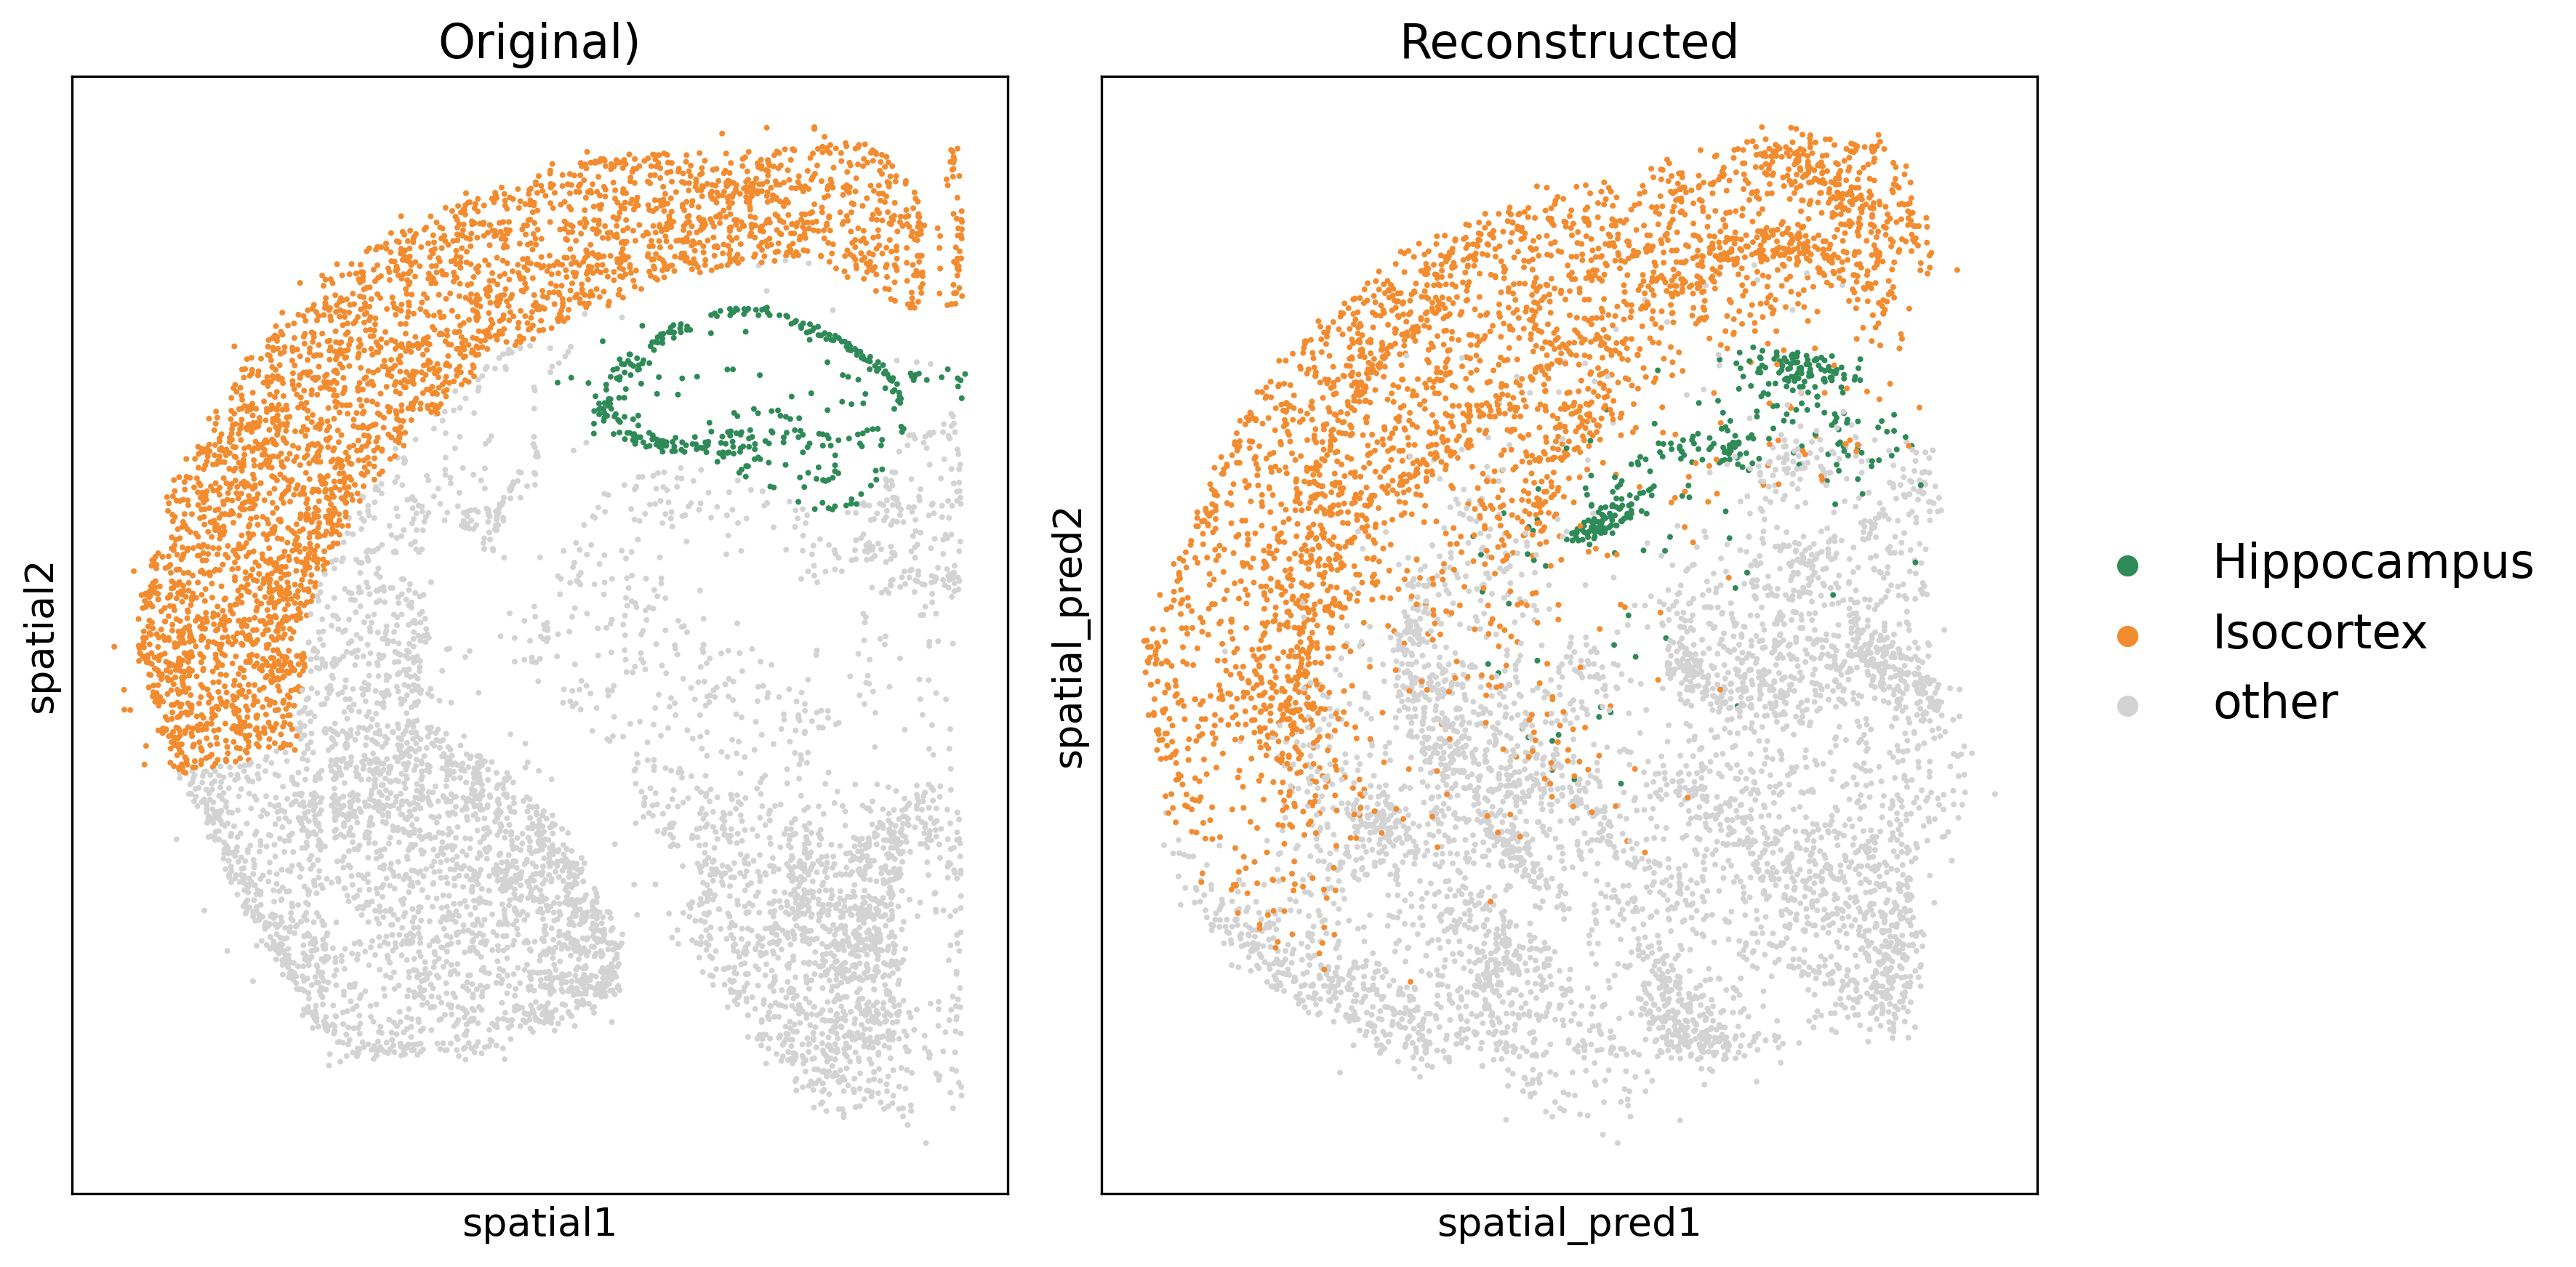

In [19]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 13

sc_adata.obs['cluster_highlight'] = 'other'

targets = ['Isocortex', 'Hippocampus']
mask = sc_adata.obs['major_brain_region'].isin(targets)
sc_adata.obs.loc[mask, 'cluster_highlight'] = sc_adata.obs.loc[mask, 'major_brain_region']

highlight_colors = {'Isocortex': "#F38B2F",  'Hippocampus': "#2E8A57", 'other': 'lightgrey'}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plt.sca(axes[0])
sc.pl.embedding(sc_adata, basis='spatial', color='cluster_highlight', palette=highlight_colors, 
                title='Original)', show=False, legend_loc=None, ax=axes[0])

plt.sca(axes[1])
sc.pl.embedding(sc_adata, basis='spatial_pred', color='cluster_highlight', palette=highlight_colors, 
                title='Reconstructed', legend_fontsize='large', show=False, ax=axes[1])

plt.tight_layout()
plt.show()

## Data Saving

In [20]:
import os
output_dir = "/.../cellPos_analysis/Mouse_Brain/Ref_10X/"
os.makedirs(output_dir, exist_ok=True)
sc_adata.write(f"{output_dir}/sc_Coronal_Merfish_Ref_10X.h5ad")
st_adata.write(f"{output_dir}/st_Coronal_Merfish_Ref_10X.h5ad")

import torch
sc_embed_model_save_path = os.path.join(output_dir, 'sc_embed_model_Coronal_Merfish_Ref_10X.pth')
st_embed_model_save_path = os.path.join(output_dir, 'sc_embed_model_Coronal_Merfish_Ref_10X.pth')
pred_model_save_path = os.path.join(output_dir, 'sc_pred_model_Coronal_Merfish_Ref_10X.pth')
torch.save(m_sc, sc_embed_model_save_path) 
torch.save(m_st, st_embed_model_save_path) 
torch.save(m_p, pred_model_save_path) 